# Stage 1 — Water percolating through a deformable ice matrix

Two-phase flow (McKenzie 1984): liquid water moves through a porous ice matrix by **Darcy flow**,
and the matrix **compacts or dilates** viscously to make room.

With constant matrix viscosity and permeability k ∝ φⁿ, the 1D equations reduce to a single
"magma equation" (Barcilon & Richter 1986; Spiegelman 1993). Dimensionless form:

$$\frac{\partial \phi}{\partial t} + \frac{\partial \phi^n}{\partial z} - \frac{\partial}{\partial z}\left(\phi^n \frac{\partial}{\partial z}\frac{\partial \phi}{\partial t}\right) = 0$$

- φ: porosity scaled by the background porosity φ₀ (so the background is φ = 1)
- z: height (+ up) scaled by the **compaction length** δ, the length over which matrix viscosity and Darcy flow balance
- t: time scaled by δ / w₀, with w₀ the background percolation velocity
- n = 3 (permeability ∝ φ³)

Each step has two parts: solve an *elliptic* equation for the compaction rate C = ∂φ/∂t, then update φ.

**Benchmark:** a localised porosity pulse that travels **without changing shape** (a solitary wave).
Its shape is known analytically, and its speed is c = 2A + 1 for amplitude A.

A = 2: speed c =  5, max ODE residual = 6.4e-06, width (phi > 1.01) = 25.2 compaction lengths
A = 5: speed c = 11, max ODE residual = 5.7e-05, width (phi > 1.01) = 36.0 compaction lengths
A = 8: speed c = 17, max ODE residual = 1.5e-04, width (phi > 1.01) = 48.3 compaction lengths


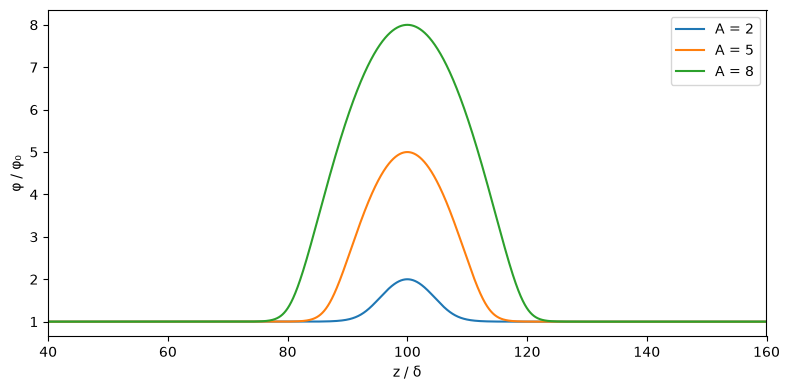

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.linalg import solve_banded

def solitary_wave_profile(A):
    """Analytic solitary wave for n=3, m=0 (Barcilon & Richter 1986).
    Returns (distance from crest, phi). Parametrised by s = sqrt(A - phi) so both the
    crest (s -> 0) and the tails (s -> sqrt(A-1)) are well resolved."""
    a = np.sqrt(A - 1.0)
    s = np.concatenate([np.linspace(0, 0.9 * a, 2000, endpoint=False),
                        a * (1 - np.geomspace(0.1, 1e-10, 2000))])
    dist = np.sqrt(A + 0.5) * (2 * s - np.log((a - s) / (a + s)) / a)
    keep = np.concatenate([[True], np.diff(dist) > 0])   # guard against round-off in the far tail
    return dist[keep], A - s[keep]**2

def wave_on_grid(A, z, z0):
    """Solitary wave centred at z0. Interpolates s = sqrt(A - phi) with a cubic spline:
    s is smooth in distance, while interpolating phi linearly would put a kink at the crest."""
    dist, phi = solitary_wave_profile(A)
    spline = CubicSpline(dist, np.sqrt(A - phi))
    d = np.abs(z - z0)
    s = np.where(d < dist[-1], spline(np.minimum(d, dist[-1])), np.sqrt(A - 1.0))
    return A - s**2

# Check: the profile must satisfy the travelling-wave ODE
#   -c(phi-1) + (phi^3 - 1) + c phi^3 phi'' = 0,   c = 2A + 1
z = np.linspace(0, 200, 16001); dz = z[1] - z[0]
fig, ax = plt.subplots(figsize=(8, 4))
for A in (2, 5, 8):
    c = 2 * A + 1
    phi = wave_on_grid(A, z, 100)
    p = phi[1:-1]
    pzz = (phi[2:] - 2 * p + phi[:-2]) / dz**2
    res = -c * (p - 1) + (p**3 - 1) + c * p**3 * pzz
    print(f"A = {A}: speed c = {c:2d}, max ODE residual = {np.abs(res).max():.1e}, "
          f"width (phi > 1.01) = {np.ptp(z[phi > 1.01]):.1f} compaction lengths")
    ax.plot(z, phi, label=f"A = {A}")
ax.set_xlabel("z / δ"); ax.set_ylabel("φ / φ₀"); ax.legend(); ax.set_xlim(40, 160)
plt.tight_layout(); plt.show()

## Solver

Each time step:
1. **Elliptic solve** for the compaction rate C = ∂φ/∂t:  C − ∂z(K ∂z C) = −∂z K, with K = φⁿ.
   Second-order finite differences, K on cell faces (arithmetic mean), C = 0 at both ends (far field).
   The matrix is tridiagonal, so `solve_banded` costs O(N).
2. **Update φ** with SSP-RK3, a three-stage Runge–Kutta scheme that is accurate to third order in time.

In [3]:
def compaction_rate(phi, dz, n=3):
    """Solve  C - d/dz( K dC/dz ) = -dK/dz,  K = phi^n,  for C = dphi/dt."""
    K = phi**n
    Kf = 0.5 * (K[1:] + K[:-1])                     # faces i+1/2, length N-1
    N = phi.size
    ab = np.zeros((3, N))                           # banded storage: [upper, diagonal, lower]
    rhs = np.zeros(N)
    ab[1, :] = 1.0
    ab[1, 1:-1] += (Kf[1:] + Kf[:-1]) / dz**2
    ab[0, 2:] = -Kf[1:] / dz**2                     # coefficient of C_{i+1} in row i
    ab[2, :-2] = -Kf[:-1] / dz**2                   # coefficient of C_{i-1} in row i
    rhs[1:-1] = -(Kf[1:] - Kf[:-1]) / dz
    # end rows: identity with rhs = 0  ->  C = 0 at both boundaries
    return solve_banded((1, 1), ab, rhs)

def run(phi0, dz, t_end, dt, n=3):
    """Advance phi from t = 0 to t_end with SSP-RK3."""
    phi = phi0.copy()
    t = 0.0
    while t < t_end - 1e-12:
        h = min(dt, t_end - t)
        k1 = phi + h * compaction_rate(phi, dz, n)
        k2 = 0.75 * phi + 0.25 * (k1 + h * compaction_rate(k1, dz, n))
        phi = phi / 3 + 2 / 3 * (k2 + h * compaction_rate(k2, dz, n))
        t += h
    return phi

## Benchmark — does the solitary wave survive?

Launch the analytic wave (A = 5) at z = 50, run to t = 8, and compare with the exact solution at z = 50 + c·t.
Repeat at three resolutions: for a second-order scheme, halving dz should cut the error by about 4×.

dz = 0.20: L2 error 6.96e-03, max error 2.75e-02, crest 4.9978 (exact 5.0), speed 11.000 (exact 11.0)
dz = 0.10: L2 error 1.75e-03, max error 6.90e-03, crest 4.9995 (exact 5.0), speed 11.000 (exact 11.0)
dz = 0.05: L2 error 4.37e-04, max error 1.73e-03, crest 4.9999 (exact 5.0), speed 11.000 (exact 11.0)
convergence order: [2. 2.]


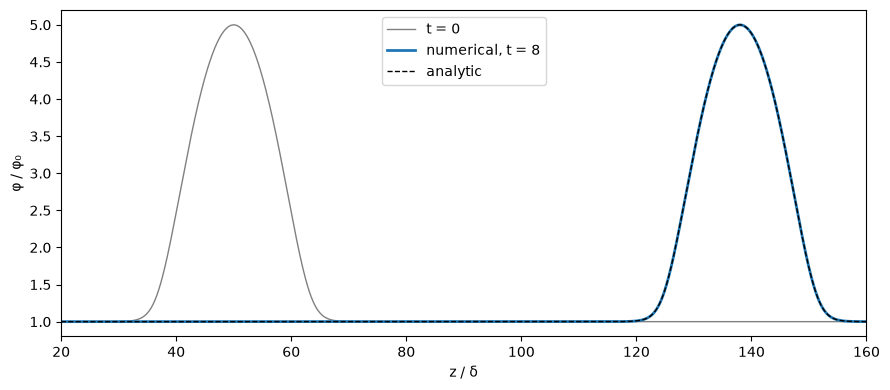

In [4]:
A, T, z0 = 5.0, 8.0, 50.0
c = 2 * A + 1
errors = []
fig, ax = plt.subplots(figsize=(9, 4))
for dz in (0.2, 0.1, 0.05):
    z = np.arange(0, 200 + dz / 2, dz)
    phi0 = wave_on_grid(A, z, z0)
    phi = run(phi0, dz, T, dt=0.5 * dz / c)          # time step tied to how far the wave moves
    exact = wave_on_grid(A, z, z0 + c * T)
    err = np.sqrt(np.mean((phi - exact) ** 2))
    errors.append(err)
    speed = (z[np.argmax(phi)] - z0) / T
    print(f"dz = {dz:4.2f}: L2 error {err:.2e}, max error {np.abs(phi - exact).max():.2e}, "
          f"crest {phi.max():.4f} (exact {A}), speed {speed:.3f} (exact {c})")
    if dz == 0.05:
        ax.plot(z, phi0, c="grey", lw=1, label="t = 0")
        ax.plot(z, phi, lw=2, label=f"numerical, t = {T:g}")
        ax.plot(z, exact, "k--", lw=1, label="analytic")

print("convergence order:", np.round(np.log2(np.array(errors[:-1]) / np.array(errors[1:])), 2))
ax.set_xlabel("z / δ"); ax.set_ylabel("φ / φ₀"); ax.set_xlim(20, 160); ax.legend()
plt.tight_layout(); plt.show()

## Experiment — what does an arbitrary pulse do?

Start from a Gaussian porosity bump (not a solitary wave). Theory says it should sort itself into solitary waves,
the largest leading, plus a trailing train of small ones. Two checks:
- the leading wave's speed should match c = 2A + 1 for *its own* amplitude A
- water mass ∫(φ − 1) dz must be conserved

leading wave: amplitude 4.019, measured speed 9.040, 2A+1 = 9.038
mass: start 42.538892, end 42.538892
min porosity: 0.563  (behind the wave, matrix compacts)


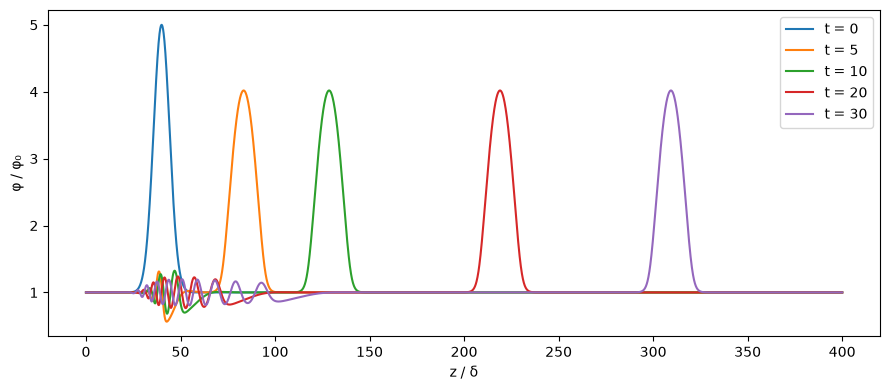

In [5]:
dz = 0.1
z = np.arange(0, 400 + dz / 2, dz)
phi = 1 + 4 * np.exp(-((z - 40) / 6) ** 2)          # Gaussian bump, crest 5
mass0 = np.trapezoid(phi - 1, z)

times = [0, 5, 10, 20, 30]
snaps, t = {0: phi.copy()}, 0
for tt in times[1:]:
    phi = run(phi, dz, tt - t, dt=0.5 * dz / 11)
    snaps[tt], t = phi.copy(), tt

# leading wave: amplitude, and speed measured between t = 20 and t = 30
A_lead = snaps[30].max()
speed = (z[np.argmax(snaps[30])] - z[np.argmax(snaps[20])]) / 10
print(f"leading wave: amplitude {A_lead:.3f}, measured speed {speed:.3f}, 2A+1 = {2*A_lead + 1:.3f}")
print(f"mass: start {mass0:.6f}, end {np.trapezoid(phi - 1, z):.6f}")
print(f"min porosity: {min(s.min() for s in snaps.values()):.3f}  (behind the wave, matrix compacts)")

fig, ax = plt.subplots(figsize=(9, 4))
for tt in times:
    ax.plot(z, snaps[tt], label=f"t = {tt}")
ax.set_xlabel("z / δ"); ax.set_ylabel("φ / φ₀"); ax.legend()
plt.tight_layout(); plt.show()


## Physical units — what does this mean inside Ganymede's high-pressure ice?

Scales (Spiegelman 1993; McKenzie 1984), with permeability k₀ = d²φ₀ⁿ / C and bulk viscosity ζ = η/φ₀:

- compaction length: δ = √( k₀ (ζ + 4η/3) / μ )
- percolation velocity: w₀ = k₀ Δρ g / (μ φ₀)
- time scale: t₀ = δ / w₀

Rough ice VI values: φ₀ = 1 %, μ_water ≈ 1.8×10⁻³ Pa s, Δρ = ρ_ice − ρ_water ≈ 120 kg m⁻³, g ≈ 1.4 m s⁻², C ≈ 1000.
Grain size d and ice viscosity η are poorly known, so scan them.

In [6]:
YR = 3.156e7   # s

def physical_scales(d, eta, phi0=0.01, C=1000.0, n=3, mu=1.8e-3, drho=120.0, g=1.4):
    k0 = d**2 * phi0**n / C                   # background permeability [m^2]
    zeta = eta / phi0                          # bulk viscosity [Pa s]
    delta = np.sqrt(k0 * (zeta + 4 / 3 * eta) / mu)
    w0 = k0 * drho * g / (mu * phi0)           # water velocity [m/s]
    return k0, delta, w0, delta / w0

A, H = 5.0, 300e3                              # wave amplitude, HP-ice thickness [m]
c = 2 * A + 1
print(f"{'d':>7} {'eta':>8} {'k0':>9} {'δ':>9} {'w0':>11} {'t0':>9} {'wave width':>11} {'crossing time':>14}")
for d in (1e-4, 1e-3, 1e-2):
    for eta in (1e14, 1e15, 1e16):
        k0, delta, w0, t0 = physical_scales(d, eta)
        print(f"{d*1e3:5.1f}mm {eta:8.0e} {k0:9.1e} {delta:7.0f} m {w0*YR:7.3f} m/yr {t0/YR:6.0f} yr "
              f"{36*delta/1e3:8.1f} km {H/(c*w0)/YR:11.1e} yr")

      d      eta        k0         δ          w0        t0  wave width  crossing time
  0.1mm    1e+14   1.0e-17       8 m   0.003 m/yr   2547 yr      0.3 km     9.3e+06 yr
  0.1mm    1e+15   1.0e-17      24 m   0.003 m/yr   8055 yr      0.9 km     9.3e+06 yr
  0.1mm    1e+16   1.0e-17      75 m   0.003 m/yr  25472 yr      2.7 km     9.3e+06 yr
  1.0mm    1e+14   1.0e-15      75 m   0.295 m/yr    255 yr      2.7 km     9.3e+04 yr
  1.0mm    1e+15   1.0e-15     237 m   0.295 m/yr    806 yr      8.5 km     9.3e+04 yr
  1.0mm    1e+16   1.0e-15     750 m   0.295 m/yr   2547 yr     27.0 km     9.3e+04 yr
 10.0mm    1e+14   1.0e-13     750 m  29.456 m/yr     25 yr     27.0 km     9.3e+02 yr
 10.0mm    1e+15   1.0e-13    2373 m  29.456 m/yr     81 yr     85.4 km     9.3e+02 yr
 10.0mm    1e+16   1.0e-13    7503 m  29.456 m/yr    255 yr    270.1 km     9.3e+02 yr
